In [1]:
!pip install datasets

  Using cached xxhash-3.6.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (13 kB)
  Using cached typer-0.24.1-py3-none-any.whl.metadata (16 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-14.3.3-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 618.0/618.0 kB 9.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 55.4 MB/s  0:00:00
Using cached typer-0.24.1-py3-none-any.whl (56 kB)
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
Using cached rich-14.3.3-py3-none-any.whl (310 kB)
Using cached markdown_it_py-4.0.0-py3-none-any.whl (87 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)
Using cached shellingham-1.5.4-py2.py3-none-any.whl (

In [2]:
import os

BASE_DIR = "/home/kbarbee2/.cache/huggingface/hub/datasets--ReadingTimeMachine--visual_qa_histograms/snapshots/f7ba35f3751cf2b27c943ccb1d313424897c913b/example_hists"

IMG_DIR = os.path.join(BASE_DIR, "imgs/imgs")
JSON_DIR = os.path.join(BASE_DIR, "jsons")

In [4]:
import json
from PIL import Image

# pick one file
json_file = os.listdir(JSON_DIR)[0]

json_path = os.path.join(JSON_DIR, json_file)
img_path = os.path.join(IMG_DIR, json_file.replace(".json", ".jpeg"))

# load
with open(json_path) as f:
    sample_json = json.load(f)

image = Image.open(img_path).convert("RGB")

print(json_file)
print(image.size)

id_0000.json
(799, 600)


In [5]:
def extract_vqa(sample):
    qa_list = []
    
    for level in sample["VQA"].values():
        for section in level.values():
            for qtype in section:
                for plot in section[qtype].values():
                    
                    question = plot["question"]
                    answer_dict = plot["A"]
                    
                    # flatten answer
                    answer = list(answer_dict.values())[0]
                    if isinstance(answer, dict):
                        answer = list(answer.values())[0]
                    
                    qa_list.append({
                        "question": question,
                        "answer": answer,
                        "type": qtype
                    })
    
    return qa_list

In [7]:
dataset = []

for json_file in os.listdir(JSON_DIR):
    if not json_file.endswith(".json"):
        continue
    
    json_path = os.path.join(JSON_DIR, json_file)
    img_path = os.path.join(IMG_DIR, json_file.replace(".json", ".jpeg"))
    
    # skip if image missing
    if not os.path.exists(img_path):
        continue
    
    with open(json_path) as f:
        sample_json = json.load(f)

    # fix double-encoded JSON
    if isinstance(sample_json, str):
        sample_json = json.loads(sample_json)

    qa_pairs = extract_vqa(sample_json)
    
    dataset.append({
        "image_path": img_path,
        "qa_pairs": qa_pairs
    })

print("Total samples:", len(dataset))

Total samples: 80


In [8]:
sample = dataset[0]

print(sample["image_path"])
print(sample["qa_pairs"][0])

/home/kbarbee2/.cache/huggingface/hub/datasets--ReadingTimeMachine--visual_qa_histograms/snapshots/f7ba35f3751cf2b27c943ccb1d313424897c913b/example_hists/imgs/imgs/id_0000.jpeg
{'question': 'How many bars are there in the specified figure panel?', 'answer': 50, 'type': 'nbars'}


In [9]:
def load_image(path):
    from PIL import Image
    return Image.open(path).convert("RGB")

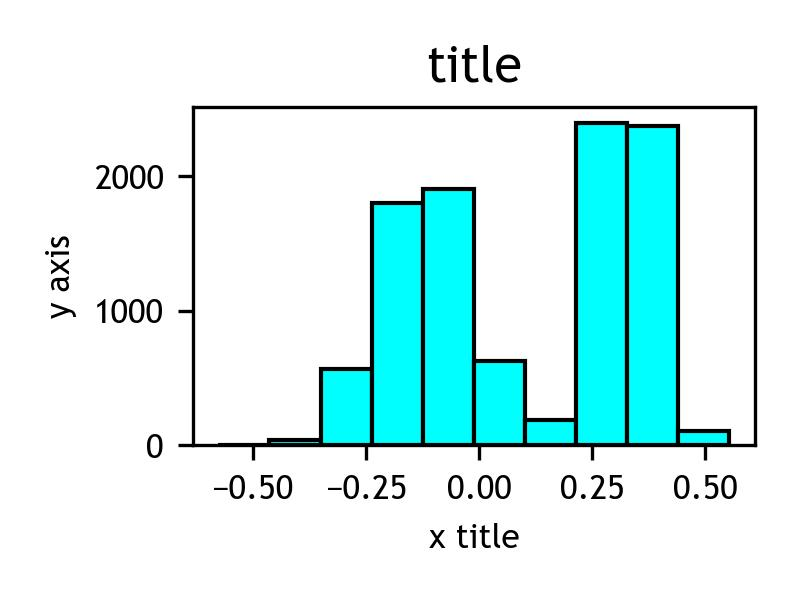

In [13]:
load_image(dataset[2]["image_path"])